In [ ]:
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)


In [3]:
drds <- "/DATA/User/liqian7/pienapple/04AS_updata/02figure2/00data/00data/"
dout <- "/DATA/User/liqian7/pienapple/04AS_updata/02figure2/02result/"
###findDEG singlecell 2000 2000HVGgne to pcoa pca pearson
sc <- readRDS("/DATA/User/liqian7/pienapple/00AS_project/82plot_figure/11spilt_sc_Fib_sc/AS_sc_spilt_fib_V2.RDS")
HVG <- FindVariableFeatures(sc, selection.method = "vst", nfeatures = 2000) 
gene <- HVG@assays$RNA@var.features

In [4]:
group <- read.csv("/DATA/User/liqian7/pienapple/06final_ST_AS_update/00data/shell/area_sample.csv",row.names=1)

In [5]:
drds <- "/DATA/User/liqian7/pienapple/06final_ST_AS_update/00data/08RDS_fin/"
dout <- "/DATA/User/liqian7/pienapple/06final_ST_AS_update/00data/09mergedata/"
setwd("/DATA/User/liqian7/pienapple/06final_ST_AS_update/01figure2/02result/")

In [3]:
n <- 0
for (s in Sys.glob(file.path(drds,"*_fn.RDS"))){
    n <- n+1
    key <- gsub("_fn.RDS", "",basename(s))
    #id <- group[which(rownames(group)==key),]$id
    rds <- paste0(drds, key,"_fn.RDS")
    pbmc <- readRDS(rds)
    pbmc <- NormalizeData(pbmc,normalization.method = "LogNormalize")
    counts <- data.frame(rowSums(as.matrix(pbmc@assays$RNA@counts)))
    colnames(counts) <- paste0(key)
    if(n==1){
        m <- counts
    }
    else{
        m <- merge(m,counts,all=TRUE,by=0)
        rownames(m) <- m$Row.names
        m <- m[,-1]
    }
}

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”


In [6]:
mer1 <- replace(m, is.na(m), 0)

In [7]:
#创建seurat对象
sp<-CreateSeuratObject(counts =mer1, 
                       project = "SeuratObject",
                       min.cells = 6,#
                       min.features = 200)#

In [9]:
group1 <- subset(group,select = c('chip_id','length_final','length_new','length','chip','week','location','sample','id','group','area','area1'))

In [ ]:
sp@meta.data <- merge(sp@meta.data,group1,all = TRUE,by = 0)
rownames(sp@meta.data) <- sp@meta.data$Row.names
sp@meta.data <- sp@meta.data[,-1]

In [ ]:
sp1 <- NormalizeData(sp,normalization.method = "LogNormalize",scale.factor = 100000)

In [ ]:
sp1@meta.data$week <- str_replace(sp1@meta.data$week,"con","N")

In [ ]:
saveRDS(sp1,paste0(dout,"all_bulk.RDS"))

In [56]:
sp1 <- readRDS(paste0(dout,"all_bulk.RDS"))
sp1

An object of class Seurat 
25277 features across 89 samples within 1 assay 
Active assay: RNA (25277 features, 0 variable features)

In [57]:
exp <- as.data.frame(sp1@assays$RNA@data)
exp1 <- subset(exp,subset = rownames(exp)%in%gene)

[1] "W10"   "W6"    "W2"    "W20"   "W20_N" "W0"

[1] "PCA1 (84.26%)"
[1] "PCA2 (7.47%)"


png 
  2

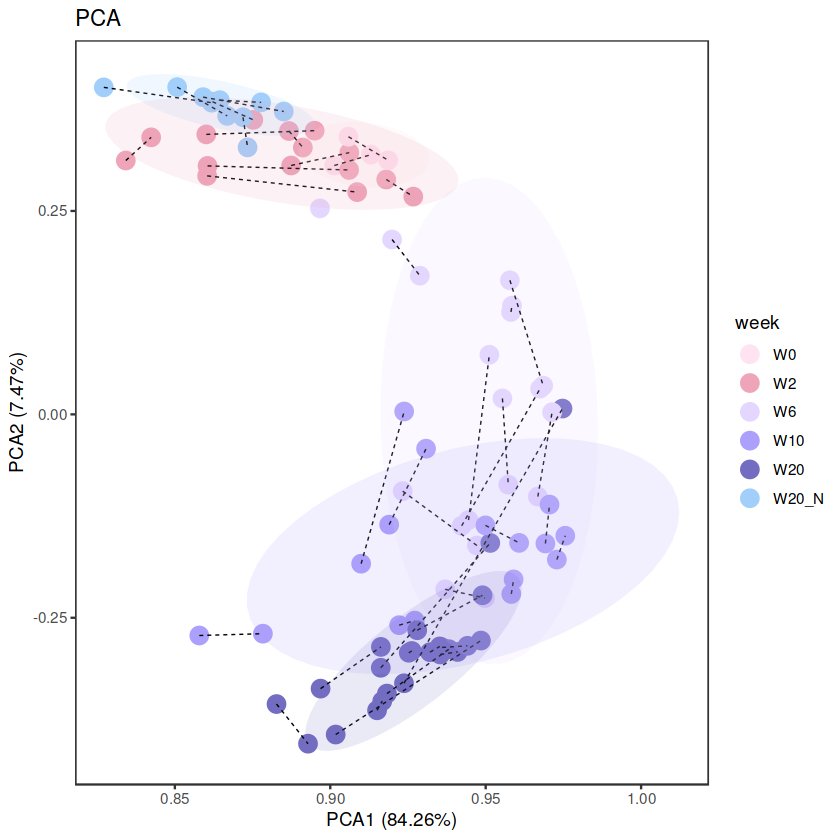

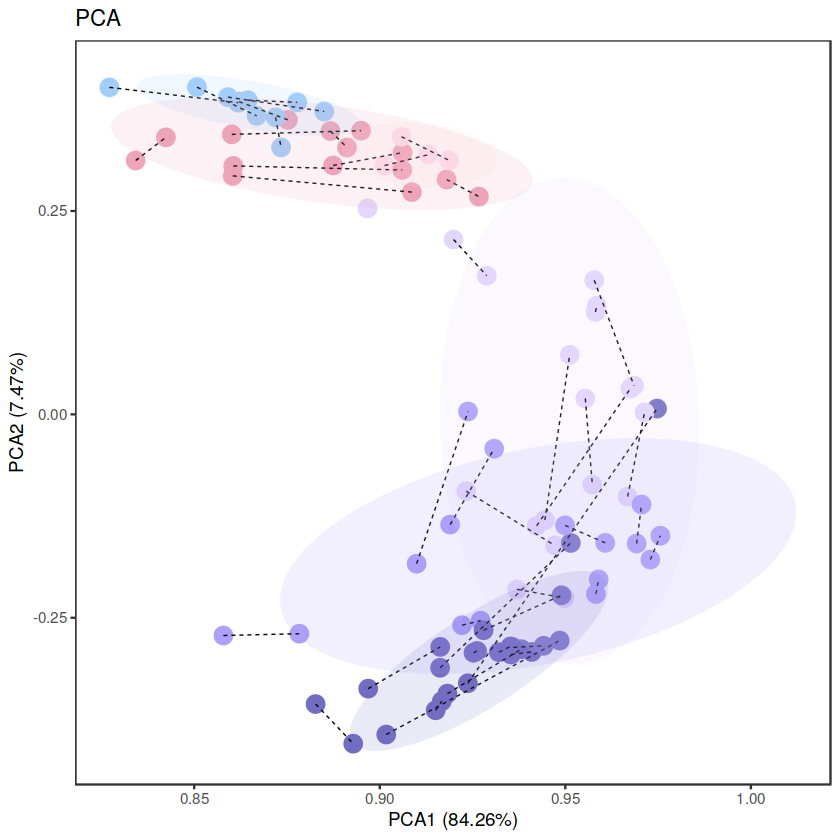

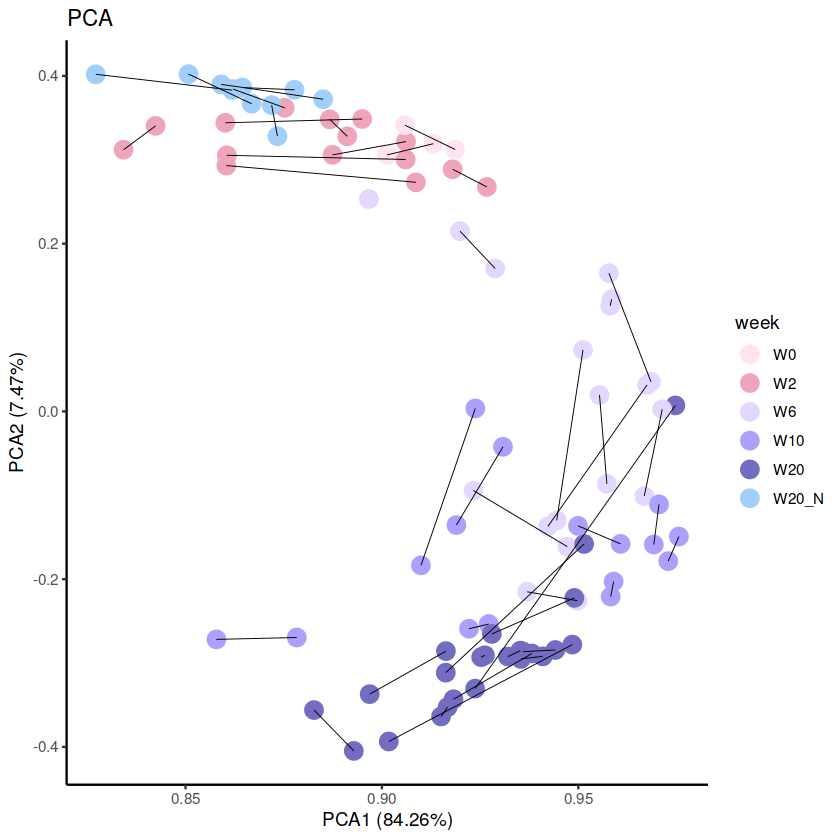

In [61]:
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
res.pca <-PCA((exp1), graph = FALSE)
eig.val <- get_eigenvalue(res.pca)
var <- get_pca_var(res.pca)
df1 <- merge(var$coord,sp1@meta.data,all = TRUE,by = 0)
rownames(df1) <- df1$Row.names
unique(df1$week)
order <- c('W0','W2','W6','W10','W20','W20_N')
df1$week <- factor(df1$week,levels = order)
cell_type_cols <- c('W0'= '#FFE3F0','W2'='#EFA5B9','W6'='#E4D7FF','W10'='#ABA0FB','W20'='#736DC2','W20_N'="#A1CFFA")

pca1 = round(eig.val[1, 2], 2)
pca2 = round(eig.val[2, 2], 2)
xlab = paste0("PCA1 (",pca1,"%)")
ylab = paste0("PCA2 (",pca2,"%)")
print(xlab)
print(ylab)
p<-ggplot(data = df1, aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=week))+ 
scale_color_manual(values = cell_type_cols)+
  theme_bw()+theme(panel.grid = element_blank())+
geom_line(aes(group=chip),size=0.3,linetype="dashed")+
stat_ellipse(data = df1,geom="polygon",level = 0.90,alpha = 0.15,linetype=1,aes(fill=week))+
scale_fill_manual(values = cell_type_cols)+
guides(fill=F)+##隐藏图例
  labs(x=xlab,y=ylab,title= "PCA")
p1 <- p+theme(legend.position = "none")
#用ggplot2画图，然后添加一个表示分组的椭圆
p3 <- ggplot(data = df1, aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=week))+ 
scale_color_manual(values = cell_type_cols)+
  theme_bw()+theme(panel.grid = element_blank())+
geom_line(aes(group=chip),size=0.2)+
  labs(title= "PCA",x=xlab,y=ylab)+theme_classic()
pdf("pca_elisp.pdf",width = 6,height = 6)
print(p)
print(p1)
print(p3)
dev.off()
print(p)
print(p1)
print(p3)

In [63]:
####calculate
df1$x <- df1$`Dim.1`
df1$y <- df1$`Dim.2`

In [64]:
chip <- as.data.frame(table(df1$chip))
colnames(chip) <- c("chip","num")

In [65]:
c1 <- subset(chip,subset = num>1)
sa <- as.character(c1$chip)

In [66]:
df2 <- subset(df1,subset = chip%in%sa)

In [67]:
df2$chip_dist <- 0
df2$median_dist <- 0

In [69]:
order <- c('W0','W2','W6','W10','W20',"W20_N")
b=0
for(a in order){
    print(a)
    b=b+1
    w <- subset(df2,subset = week==a)
    for(c in unique(w$chip)){
        w1  <- subset(w,subset = chip==c)
        n=0
        for(i in unique(w1$chip_id)){
            n=n+1
            chip1 <- subset(w1,subset = chip_id==i)
            chip2 <- subset(w1,subset = chip_id!=i)
            x <- chip1$x
            y <- chip1$y
            x1 <- chip2$x
            y1 <- chip2$y
            dist <- as.numeric(crossdist(x1, y1, x, y))
            chip_dist <- dist
            chip3 <- subset(w,subset = chip!=unique(chip1$chip))
            d = 0
            for(s in unique(chip3$chip_id)){
                d=d+1
                chip3 <- subset(chip3,subset =chip_id==s)
                x2 <- chip3$x
                y2 <- chip3$y
                dist1 <- as.numeric(crossdist(x2, y2, x, y))
                if(d==1){
                    m <- dist1
                }
                else{
                    m <- rbind(m,dist1)
                }
                }
            median_dist <- median(m)
            df2[which(rownames(df2)==i),]$chip_dist <- chip_dist
            df2[which(rownames(df2)==i),]$median_dist <- median_dist
        }
    }
}

[1] "W0"
[1] "W2"
[1] "W6"
[1] "W10"
[1] "W20"
[1] "W20_N"


In [77]:
saveRDS(df2,"chip_dist_median_dist1_df.RDS")

In [6]:
df2 <- readRDS("./dist_chip_median_df2.RDS")

In [7]:
colnames(df2) <- str_replace(colnames(df2),"Row.names","rown")

In [8]:
chip_dist <- subset(df2,select = c("rown","week","chip_dist"))
chip_dist$type <- "chip_dist"
colnames(chip_dist) <- c("rown","week","dist","type")
median_dist <- subset(df2,select = c("rown","week","median_dist"))
median_dist$type <- "median_dist"
colnames(median_dist) <- c("rown","week","dist","type")

In [9]:
mer <- rbind(chip_dist,median_dist)

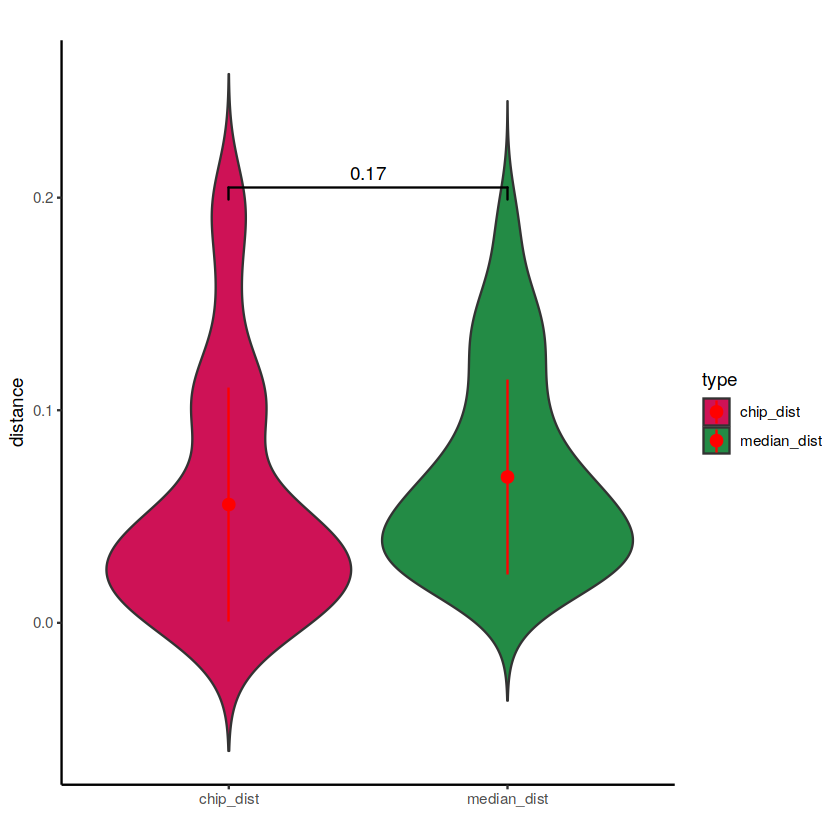

In [10]:
p0 <- ggplot(mer,aes(x=type,y=dist,fill=type))+geom_violin(trim = FALSE) +
    stat_summary(fun.data="mean_sdl", fun.args = list(mult=1),
               geom="pointrange", color = "red") +
    labs(title="",x="",y="distance")+geom_signif(comparisons = list(c('median_dist','chip_dist')),test = "t.test",step_increase = 0.2)+scale_fill_manual(values = c('chip_dist'="#ce1256",'median_dist'="#238b45"))+
    theme_classic ()
p0

In [16]:
mer$week <- str_replace(mer$week,"W20_con","N_W20")
unique(mer$week)

[1] "W10"   "W2"    "W20"   "W6"    "N_W20" "W0"

In [17]:
mer$week <- factor(mer$week,levels = c("N_W20",'W0','W2','W6','W10','W20'))

In [20]:
setwd("./06ST_mm_shape_ann_ann2/")

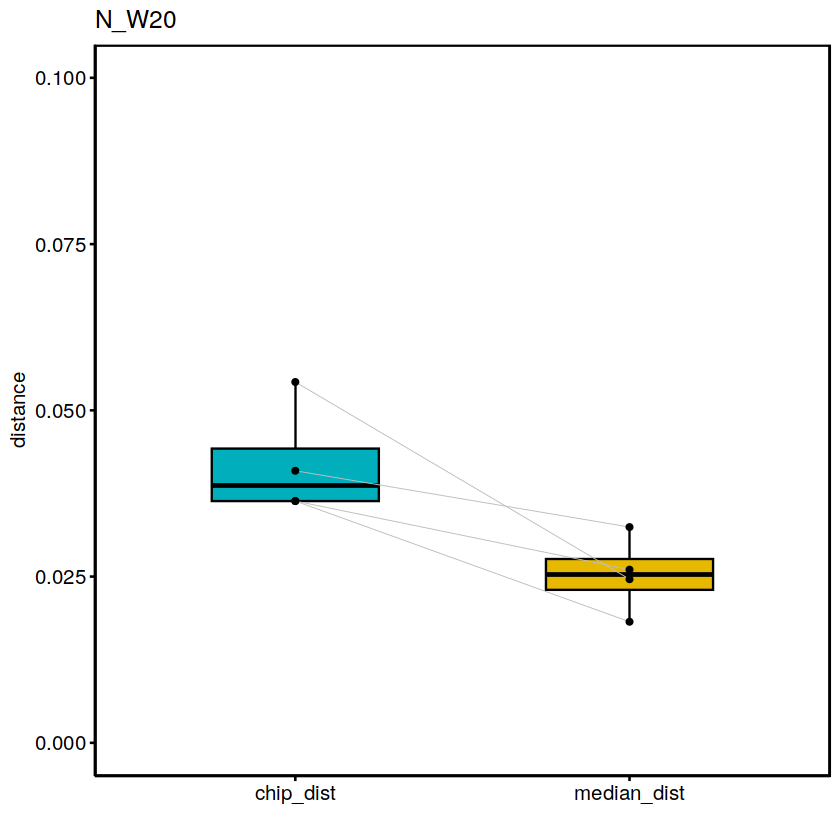

In [19]:
i<-"N_W20"
mer1 <- subset(mer,subset = week==i)
p1 <- ggpaired(mer1, x="type", y="dist", fill="type",id = "id",
                   add="jitter",line.color = "gray", line.size = 0.2,
                   palette=c('#00AFBB', '#E7B800'),
                   xlab=" ",linewidth = 0.04,
                   ylab="distance", title = i,
                   legend.title=" ",show.legend = F) + 
theme(legend.position = 'none',panel.border = element_rect(linetype = 'solid', size = 1,fill = NA))+coord_cartesian(ylim = c(0, 0.1))
print(p1)
ggsave(paste0(i,"_s1.pdf"),p1,width=4,height = 4)